### Explortory Data Analysis (EDA)

In [339]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import hierarchicalforecast
import statsforecast
from statsforecast.models import AutoARIMA
from statsforecast.models import AutoETS
pd.set_option('display.max_columns', None)

#### 1. Load Data

In [340]:
df_dataset = pd.read_parquet('../../data/gold/forecasting/ds_base_dataset.parquet')
df_dim_timeseries = pd.read_parquet('../../data/gold/data_warehouse/dw_dim_time_series.parquet')

### 2. Basic dataframe infos

In [341]:
df_dataset.shape

(203471, 40)

This dataset contains 203,679 rows and 27 columns. It's not a small dataset, but it's not huge either

In [342]:
df_dataset.pivot_table(
    index='supplier_name',
    columns='region_name',
    values='units_sold',
    aggfunc='sum',
    fill_value=0
).head()

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\2715419121.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_dataset.pivot_table(


region_name,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
supplier_name,,,,,
Supplier 1,0,0,0,0,214270
Supplier 10,16457,108,827,314,1658
Supplier 11,0,0,0,0,62522
Supplier 12,5557,13772,1781,19459,10101
Supplier 13,24,0,1,195855,83521


In [343]:
df_dataset.head(5)

,time_series_id,week_date,supplier_id,region_id,product_id,units_sold,week,start_date,end_date,year,semester,semester_date,semester_name,quarter,quarter_date,quarter_name,month,month_name,month_date,first_week_date,last_week_date,total_weeks_length,num_week_with_sales,sales_weeks_ratio,sales_units,avg_weekly_sales,std_weekly_sales,max_weekly_sales,min_weekly_sales,q25_sales,q50_sales,q75_sales,iqr,cv,supplier_name,region_name,product_name,product_attribute_1,product_attribute_2,product_attribute_3
0,1,2023-01-09,1,5,69,2,2,2023-01-09,2023-01-15,2023,1,2023-01-01,H1,1,2023-01-01,Q1,1,January,2023-01-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
1,1,2023-01-16,1,5,69,6,3,2023-01-16,2023-01-22,2023,1,2023-01-01,H1,1,2023-01-01,Q1,1,January,2023-01-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
2,1,2023-01-23,1,5,69,0,4,2023-01-23,2023-01-29,2023,1,2023-01-01,H1,1,2023-01-01,Q1,1,January,2023-01-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
3,1,2023-01-30,1,5,69,0,5,2023-01-30,2023-02-05,2023,1,2023-01-01,H1,1,2023-01-01,Q1,1,January,2023-01-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
4,1,2023-02-06,1,5,69,0,6,2023-02-06,2023-02-12,2023,1,2023-02-01,H1,1,2023-01-01,Q1,2,February,2023-02-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04


In [344]:
df_dataset.tail(5)

,time_series_id,week_date,supplier_id,region_id,product_id,units_sold,week,start_date,end_date,year,semester,semester_date,semester_name,quarter,quarter_date,quarter_name,month,month_name,month_date,first_week_date,last_week_date,total_weeks_length,num_week_with_sales,sales_weeks_ratio,sales_units,avg_weekly_sales,std_weekly_sales,max_weekly_sales,min_weekly_sales,q25_sales,q50_sales,q75_sales,iqr,cv,supplier_name,region_name,product_name,product_attribute_1,product_attribute_2,product_attribute_3
203466,2845,2024-07-29,27,4,381,0,31,2024-07-29,2024-08-04,2024,2,2024-07-01,H2,3,2024-07-01,Q3,7,July,2024-07-01,2024-04-29,2024-08-26,18,3,0.166667,11,0.611111,1.577,6,0,0,0,0,0.0,2.580541,Supplier 27,Sudeste,Product 381,B,C,B31
203467,2845,2024-08-05,27,4,381,0,32,2024-08-05,2024-08-11,2024,2,2024-08-01,H2,3,2024-07-01,Q3,8,August,2024-08-01,2024-04-29,2024-08-26,18,3,0.166667,11,0.611111,1.577,6,0,0,0,0,0.0,2.580541,Supplier 27,Sudeste,Product 381,B,C,B31
203468,2845,2024-08-12,27,4,381,0,33,2024-08-12,2024-08-18,2024,2,2024-08-01,H2,3,2024-07-01,Q3,8,August,2024-08-01,2024-04-29,2024-08-26,18,3,0.166667,11,0.611111,1.577,6,0,0,0,0,0.0,2.580541,Supplier 27,Sudeste,Product 381,B,C,B31
203469,2845,2024-08-19,27,4,381,0,34,2024-08-19,2024-08-25,2024,2,2024-08-01,H2,3,2024-07-01,Q3,8,August,2024-08-01,2024-04-29,2024-08-26,18,3,0.166667,11,0.611111,1.577,6,0,0,0,0,0.0,2.580541,Supplier 27,Sudeste,Product 381,B,C,B31
203470,2845,2024-08-26,27,4,381,2,35,2024-08-26,2024-09-01,2024,2,2024-08-01,H2,3,2024-07-01,Q3,8,August,2024-08-01,2024-04-29,2024-08-26,18,3,0.166667,11,0.611111,1.577,6,0,0,0,0,0.0,2.580541,Supplier 27,Sudeste,Product 381,B,C,B31


In [346]:
df_dataset.dtypes

time_series_id                  int32
week_date              datetime64[ns]
supplier_id                     int64
region_id                       int64
product_id                      int64
units_sold                      Int64
week                            int16
start_date             datetime64[ns]
end_date               datetime64[ns]
year                            int16
semester                        int16
semester_date          datetime64[ns]
semester_name                category
quarter                         int16
quarter_date           datetime64[ns]
quarter_name                 category
month                           int16
month_name                   category
month_date             datetime64[ns]
first_week_date        datetime64[ns]
last_week_date         datetime64[ns]
total_weeks_length              Int64
num_week_with_sales             Int64
sales_weeks_ratio             float32
sales_units                     Int64
avg_weekly_sales              float32
std_weekly_s

# Descritive statistics

In [347]:
pd.read_csv('../../data/raw/dataset-case-iqvia.csv').min()

week_dt             2022-11-01
dsupp_id                     1
product_id                   1
region_nm         Centro-Oeste
units_qty                 0.01
product_attr_1               A
product_attr_2               A
product_attr_3             A01
dtype: object

In [348]:
pd.read_csv('../../data/raw/dataset-case-iqvia.csv').max()

week_dt           2024-10-27
dsupp_id                  27
product_id               390
region_nm                Sul
units_qty            29006.0
product_attr_1             C
product_attr_2             C
product_attr_3           B32
dtype: object

In [349]:
n_weeks = len(df_dataset['week_date'].unique())
n_products = len(df_dataset['product_name'].unique())
n_suppliers = len(df_dataset['supplier_name'].unique())
n_regions = len(df_dataset['region_name'].unique())
print(f'Número de semanas: {n_weeks}')
print(f'Número de produtos: {n_products}')
print(f'Número de fornecedores: {n_suppliers}')
print(f'Número de regiões: {n_regions}')

n_series = df_dataset.groupby(['product_name', 'supplier_name', 'region_name'],observed=True)['units_sold'].sum().reset_index().shape[0]
print(f'Número de séries temporais: {n_series}')

df_dataset[['week_date','units_sold']].describe()

Número de semanas: 104
Número de produtos: 390
Número de fornecedores: 27
Número de regiões: 5
Número de séries temporais: 2841


,week_date,units_sold
count,203471,203471.0
mean,2023-10-31 18:44:06.191349248,41.8594
min,2022-10-31 00:00:00,0.0
25%,2023-05-08 00:00:00,0.0
50%,2023-11-06 00:00:00,2.0
75%,2024-04-22 00:00:00,11.0
max,2024-10-21 00:00:00,30384.0
std,NaN,292.448756


In [350]:
df_dim_timeseries[df_dim_timeseries['time_series_id']==1]

,time_series_id,supplier_id,region_id,product_id,first_week_date,last_week_date,total_weeks_length,num_week_with_sales,sales_units,avg_weekly_sales,std_weekly_sales,max_weekly_sales,min_weekly_sales,q25_sales,q50_sales,q75_sales,sales_weeks_ratio,cv,iqr
0,1,1,5,69,2023-01-09,2023-08-21,33,4,10.0,0.30303,1.103541,6.0,0.0,0.0,0.0,0.0,0.121212,3.641674,0.0


In [351]:
df_dataset[df_dataset['time_series_id']==1]

,time_series_id,week_date,supplier_id,region_id,product_id,units_sold,week,start_date,end_date,year,semester,semester_date,semester_name,quarter,quarter_date,quarter_name,month,month_name,month_date,first_week_date,last_week_date,total_weeks_length,num_week_with_sales,sales_weeks_ratio,sales_units,avg_weekly_sales,std_weekly_sales,max_weekly_sales,min_weekly_sales,q25_sales,q50_sales,q75_sales,iqr,cv,supplier_name,region_name,product_name,product_attribute_1,product_attribute_2,product_attribute_3
0,1,2023-01-09,1,5,69,2,2,2023-01-09,2023-01-15,2023,1,2023-01-01,H1,1,2023-01-01,Q1,1,January,2023-01-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
1,1,2023-01-16,1,5,69,6,3,2023-01-16,2023-01-22,2023,1,2023-01-01,H1,1,2023-01-01,Q1,1,January,2023-01-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
2,1,2023-01-23,1,5,69,0,4,2023-01-23,2023-01-29,2023,1,2023-01-01,H1,1,2023-01-01,Q1,1,January,2023-01-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
3,1,2023-01-30,1,5,69,0,5,2023-01-30,2023-02-05,2023,1,2023-01-01,H1,1,2023-01-01,Q1,1,January,2023-01-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
4,1,2023-02-06,1,5,69,0,6,2023-02-06,2023-02-12,2023,1,2023-02-01,H1,1,2023-01-01,Q1,2,February,2023-02-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
5,1,2023-02-13,1,5,69,0,7,2023-02-13,2023-02-19,2023,1,2023-02-01,H1,1,2023-01-01,Q1,2,February,2023-02-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
6,1,2023-02-20,1,5,69,0,8,2023-02-20,2023-02-26,2023,1,2023-02-01,H1,1,2023-01-01,Q1,2,February,2023-02-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
7,1,2023-02-27,1,5,69,0,9,2023-02-27,2023-03-05,2023,1,2023-02-01,H1,1,2023-01-01,Q1,2,February,2023-02-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
8,1,2023-03-06,1,5,69,0,10,2023-03-06,2023-03-12,2023,1,2023-03-01,H1,1,2023-01-01,Q1,3,March,2023-03-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
9,1,2023-03-13,1,5,69,0,11,2023-03-13,2023-03-19,2023,1,2023-03-01,H1,1,2023-01-01,Q1,3,March,2023-03-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.30303,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04


#The cutoff date was 2023-10-26 and goes to 2024-10-21, one year of data collected weekly. Lots of time series, and half of the distribution are zero, which makes it hard to model. Need feature engineering

### 3. Missing values

In [352]:
df_dataset.isna().sum()

time_series_id         0
week_date              0
supplier_id            0
region_id              0
product_id             0
units_sold             0
week                   0
start_date             0
end_date               0
year                   0
semester               0
semester_date          0
semester_name          0
quarter                0
quarter_date           0
quarter_name           0
month                  0
month_name             0
month_date             0
first_week_date        0
last_week_date         0
total_weeks_length     0
num_week_with_sales    0
sales_weeks_ratio      0
sales_units            0
avg_weekly_sales       0
std_weekly_sales       0
max_weekly_sales       0
min_weekly_sales       0
q25_sales              0
q50_sales              0
q75_sales              0
iqr                    0
cv                     0
supplier_name          0
region_name            0
product_name           0
product_attribute_1    0
product_attribute_2    0
product_attribute_3    0


#The raw datasets do not contain missing values, so the gold dataset as well does not contain missing values.

### 4. Missing time series

In [353]:
#exists empty series?
df_dataset.groupby(['product_name', 'supplier_name', 'region_name'],observed=True).agg({'units_sold': 'sum'}).reset_index().query('units_sold == 0')

,product_name,supplier_name,region_name,units_sold


#Improve the mean by a little, but still have some series with zero sales, but we will keep them for now, implies in sparse data and more difficult to model, but we will see how it goes.

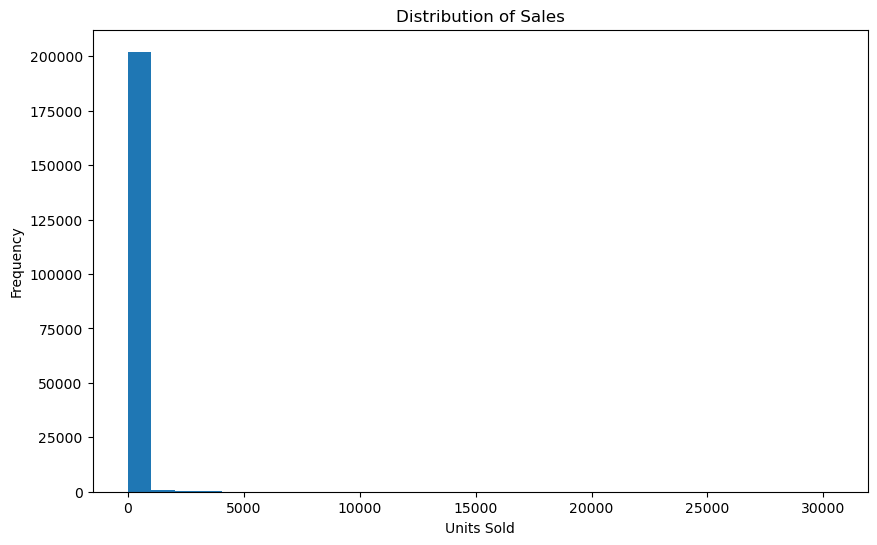

In [354]:
#Analize the distribution of sales 
plt.figure(figsize=(10,6))
plt.hist(df_dataset['units_sold'], bins=30)
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')
plt.show()

#very sparse dateset, with many zeros and few high values. We can try to model it with a zero-inflated model or a model that can handle sparse data.

### 5. Time Series Data Analisys

#### 5.1 Total Hierarchy

##### 5.1.1 By year

In [355]:
#by year
df_total_sales_yearly = df_dataset.groupby(df_dataset['week_date'].dt.year).agg(
    week_date_start=('week_date', 'min'),
    week_date_end=('week_date', 'max'),
    units_sold=('units_sold', 'sum')
).reset_index()
df_total_sales_yearly.rename(columns={'week_date': 'year'}, inplace=True)
df_total_sales_yearly.head()

,year,week_date_start,week_date_end,units_sold
0,2022,2022-10-31,2022-12-26,622040
1,2023,2023-01-02,2023-12-25,3896899
2,2024,2024-01-01,2024-10-21,3998235


<Axes: xlabel='year'>

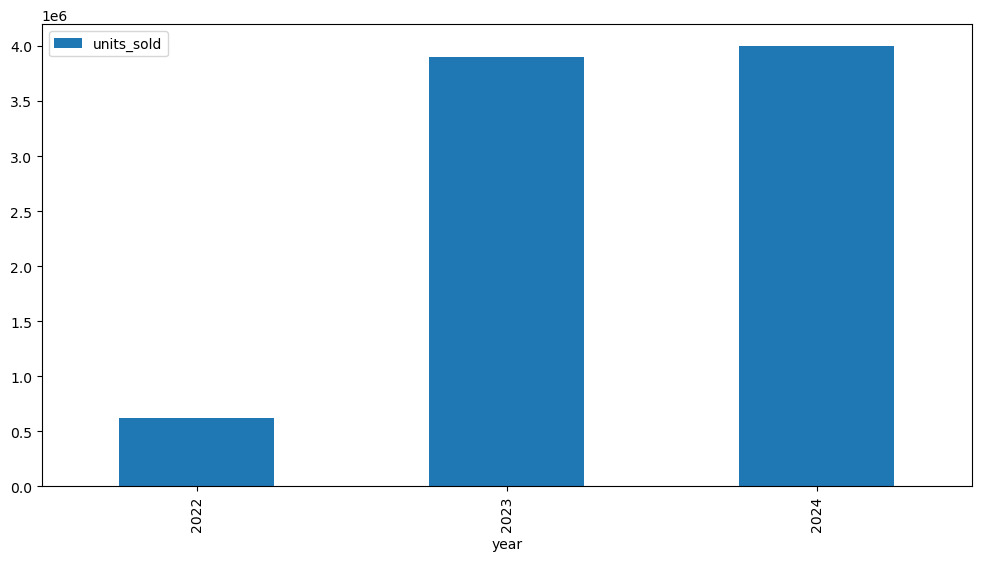

In [356]:
df_total_sales_yearly.plot(x='year', y='units_sold', kind='bar', figsize=(12,6))

#2 years of data, distribuited by 3 years, so we have 2 years with 52 weeks and 1 year with 48 weeks. We can use the first 2 years for training and the last year for testing.

##### 5.1.2 Monthly

In [357]:
df_dataset

,time_series_id,week_date,supplier_id,region_id,product_id,units_sold,week,start_date,end_date,year,semester,semester_date,semester_name,quarter,quarter_date,quarter_name,month,month_name,month_date,first_week_date,last_week_date,total_weeks_length,num_week_with_sales,sales_weeks_ratio,sales_units,avg_weekly_sales,std_weekly_sales,max_weekly_sales,min_weekly_sales,q25_sales,q50_sales,q75_sales,iqr,cv,supplier_name,region_name,product_name,product_attribute_1,product_attribute_2,product_attribute_3
0,1,2023-01-09,1,5,69,2,2,2023-01-09,2023-01-15,2023,1,2023-01-01,H1,1,2023-01-01,Q1,1,January,2023-01-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.303030,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
1,1,2023-01-16,1,5,69,6,3,2023-01-16,2023-01-22,2023,1,2023-01-01,H1,1,2023-01-01,Q1,1,January,2023-01-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.303030,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
2,1,2023-01-23,1,5,69,0,4,2023-01-23,2023-01-29,2023,1,2023-01-01,H1,1,2023-01-01,Q1,1,January,2023-01-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.303030,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
3,1,2023-01-30,1,5,69,0,5,2023-01-30,2023-02-05,2023,1,2023-01-01,H1,1,2023-01-01,Q1,1,January,2023-01-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.303030,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
4,1,2023-02-06,1,5,69,0,6,2023-02-06,2023-02-12,2023,1,2023-02-01,H1,1,2023-01-01,Q1,2,February,2023-02-01,2023-01-09,2023-08-21,33,4,0.121212,10,0.303030,1.103541,6,0,0,0,0,0.0,3.641674,Supplier 1,Sul,Product 69,A,A,A04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203466,2845,2024-07-29,27,4,381,0,31,2024-07-29,2024-08-04,2024,2,2024-07-01,H2,3,2024-07-01,Q3,7,July,2024-07-01,2024-04-29,2024-08-26,18,3,0.166667,11,0.611111,1.577000,6,0,0,0,0,0.0,2.580541,Supplier 27,Sudeste,Product 381,B,C,B31
203467,2845,2024-08-05,27,4,381,0,32,2024-08-05,2024-08-11,2024,2,2024-08-01,H2,3,2024-07-01,Q3,8,August,2024-08-01,2024-04-29,2024-08-26,18,3,0.166667,11,0.611111,1.577000,6,0,0,0,0,0.0,2.580541,Supplier 27,Sudeste,Product 381,B,C,B31
203468,2845,2024-08-12,27,4,381,0,33,2024-08-12,2024-08-18,2024,2,2024-08-01,H2,3,2024-07-01,Q3,8,August,2024-08-01,2024-04-29,2024-08-26,18,3,0.166667,11,0.611111,1.577000,6,0,0,0,0,0.0,2.580541,Supplier 27,Sudeste,Product 381,B,C,B31
203469,2845,2024-08-19,27,4,381,0,34,2024-08-19,2024-08-25,2024,2,2024-08-01,H2,3,2024-07-01,Q3,8,August,2024-08-01,2024-04-29,2024-08-26,18,3,0.166667,11,0.611111,1.577000,6,0,0,0,0,0.0,2.580541,Supplier 27,Sudeste,Product 381,B,C,B31


In [358]:
df_total_sales_monthly = (
    df_dataset
    .groupby(['year', 'month'])
    .agg(units_sold=('units_sold', 'sum'))
    .reset_index()
    .assign(period=lambda x: pd.to_datetime(x[['year', 'month']].assign(day=1)))
    .sort_values('period')
)
df_total_sales_monthly.head()

,year,month,units_sold,period
0,2022,10,114581,2022-10-01
1,2022,11,260599,2022-11-01
2,2022,12,246860,2022-12-01
3,2023,1,313500,2023-01-01
4,2023,2,269736,2023-02-01


<Axes: xlabel='period'>

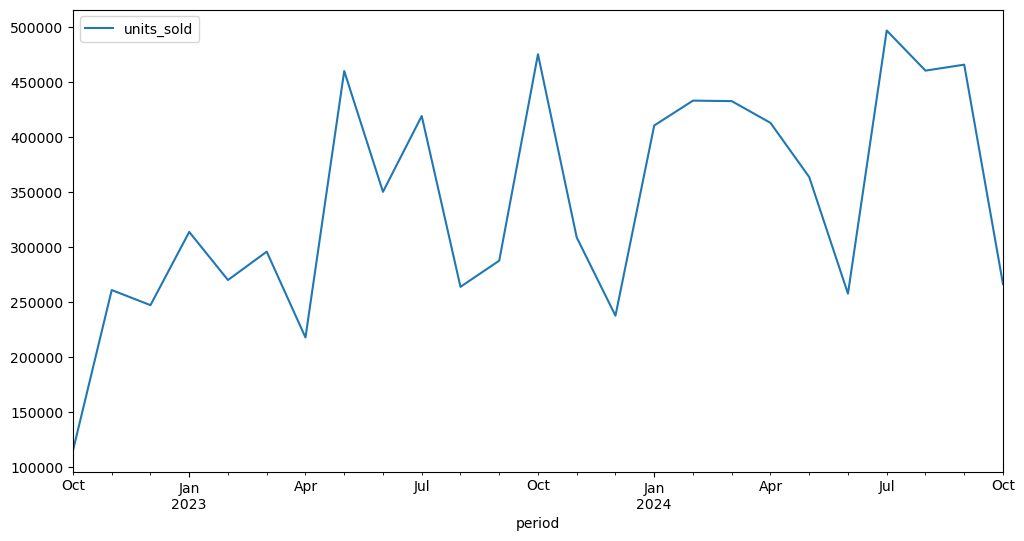

In [359]:
df_total_sales_monthly.plot(x='period', y='units_sold', kind='line', figsize=(12,6))

#Trend very clear, but with a lot of noise, not clear patterns at this level

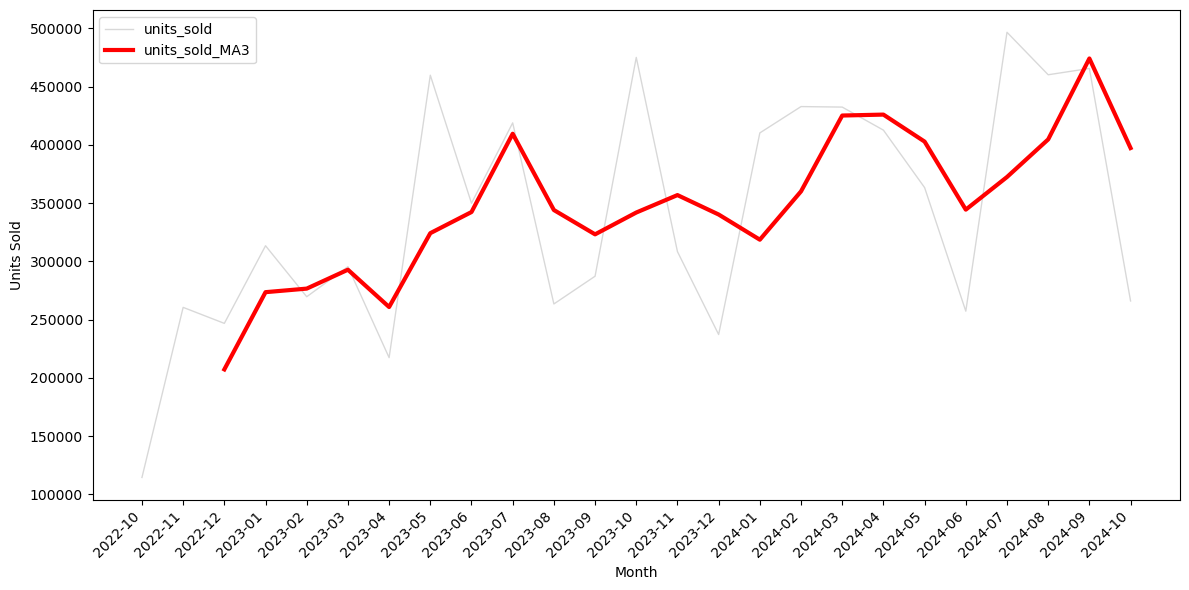

In [360]:
df_total_sales_monthly['units_sold_MA3'] = df_total_sales_monthly['units_sold'].rolling(window=3).mean()

plt.figure(figsize=(12, 6))
ax = plt.gca()

ax.plot(df_total_sales_monthly['period'].dt.strftime('%Y-%m'), df_total_sales_monthly['units_sold'],
    color='gray', alpha=0.3, linewidth=1, label='units_sold')

ax.plot(df_total_sales_monthly['period'].dt.strftime('%Y-%m'), df_total_sales_monthly['units_sold_MA3'],
    color='red', alpha=1.0, linewidth=3, label='units_sold_MA3')

ax.set_xlabel('Month')
ax.set_ylabel('Units Sold')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

#moving avarege with 3 months window to better visualize the trend and seasonality. Again we can see a clear upward trend.

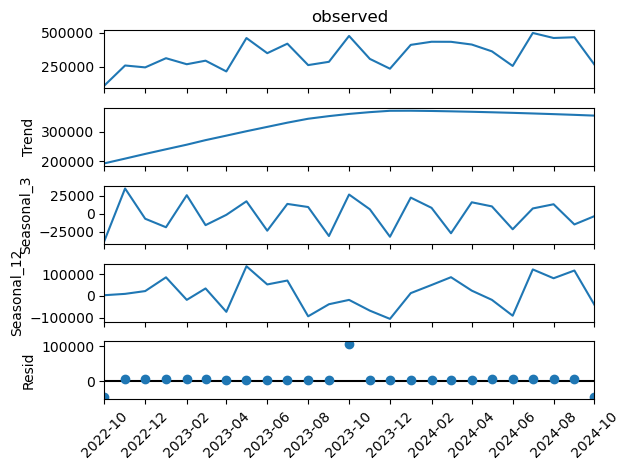

In [441]:
from statsmodels.tsa.seasonal import MSTL
import matplotlib.dates as mdates

ts = df_total_sales_monthly.set_index('period')['units_sold']

result = MSTL(ts, periods=(3, 12)).fit()

fig = result.plot()
for ax in fig.axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

**MSTL Decomposition — Monthly Total Sales (periods: 3 = quarterly, 12 = annual)**

**Trend:** After an initial decline in late 2022 — likely an artefact of the series starting mid-quarter with fewer weeks of data — total sales show a sustained upward trajectory through 2024. This may reflect organic market growth or category expansion across suppliers.

**Seasonal (quarterly, period = 3):** Recurring peaks every three months are consistent with typical pharma procurement dynamics: hospital and pharmacy budgets are frequently released on a quarterly basis, generating predictable purchase spikes. This also aligns with the strong autocorrelation at lag 4 observed in the ACF plot.

**Seasonal (annual, period = 12):** A year-level cycle is visible, with elevated sales at the start of the calendar year — consistent with new fiscal-year budget releases and prescription renewals in January, a well-documented pattern in pharmaceutical markets.

**Remainder:** Residual variance grows proportionally with the trend level — a hallmark of a **multiplicative** data-generating process. This has two direct modeling implications:
1. A **log transformation** of `units_sold` is advisable before training to stabilise variance and prevent the model from over-weighting high-volume periods.
2. Additive seasonal baselines (e.g., `SeasonalNaive`) will systematically underestimate variability at higher sales levels and are therefore unlikely to be competitive.

Occasional large spikes in the remainder are consistent with stockout-and-refill events or short-term promotional activity, as also surfaced in the outlier analysis of Product 134.

**Modeling take-away:** The decomposition motivates: (1) encoding both quarterly and annual cycles via Fourier features or seasonal lag encodings; (2) applying a log transform to the target; and (3) using a global model (LightGBM) capable of learning cross-series patterns — rather than fitting independent univariate models to each of the 2,841 sparse bottom-level series.

#### 5.1.2 Weekly

In [362]:
#Analyze top-down hierarchy
df_total_sales = df_dataset.groupby('week_date')['units_sold'].sum().reset_index()
df_total_sales.head()

,week_date,units_sold
0,2022-10-31,114581
1,2022-11-07,64134
2,2022-11-14,68566
3,2022-11-21,39839
4,2022-11-28,88060


<Axes: xlabel='week_date'>

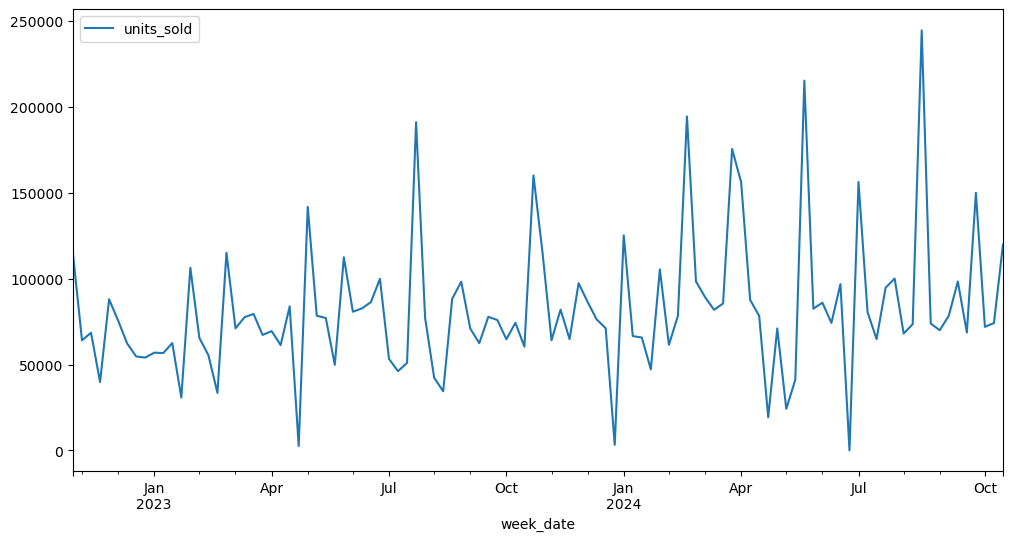

In [363]:
df_total_sales.plot(x='week_date', y='units_sold', kind='line', figsize=(12,6))

#It' possible to see a little bit of trend in the data and a seasonality pattern with peaks in the middle of the year and lower sales at the beginning and end of the year. The variability of sales also seems to increase over time, which could indicate a multiplicative seasonality pattern.

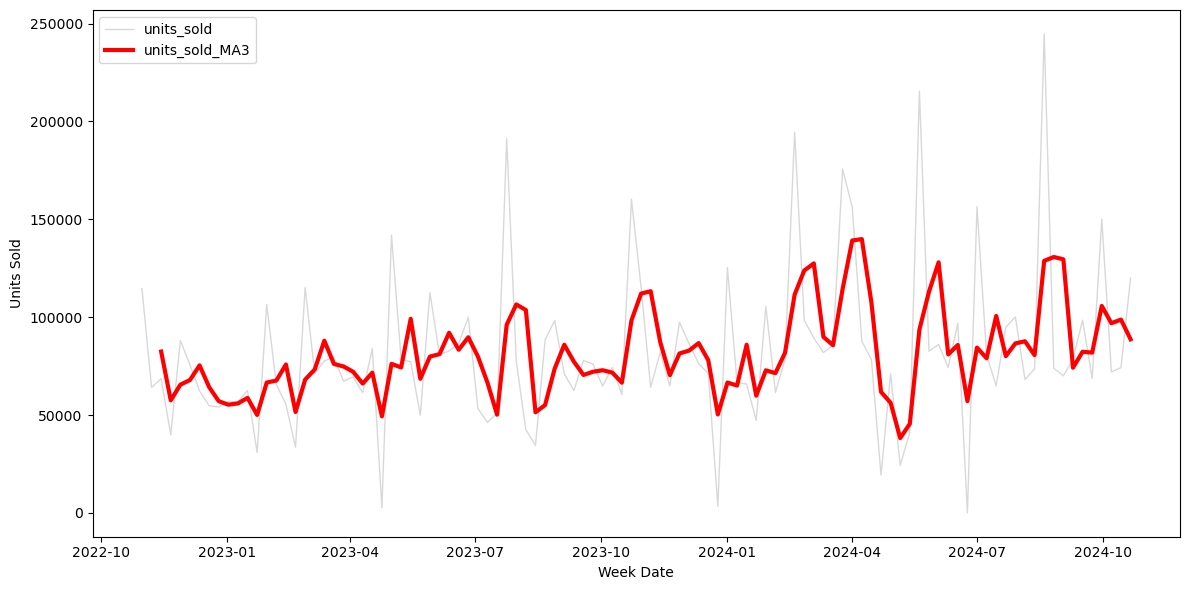

In [364]:
#### 5.1.1
df_total_sales['units_sold_MA3'] = df_total_sales['units_sold'].rolling(window=3).mean()
plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.plot(df_total_sales['week_date'], df_total_sales['units_sold'],
    color='gray', alpha=0.3, linewidth=1, label='units_sold')
ax.plot(df_total_sales['week_date'], df_total_sales['units_sold_MA3'],
    color='red', alpha=1.0, linewidth=3, label='units_sold_MA3')
ax.set_xlabel('Week Date')
ax.set_ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

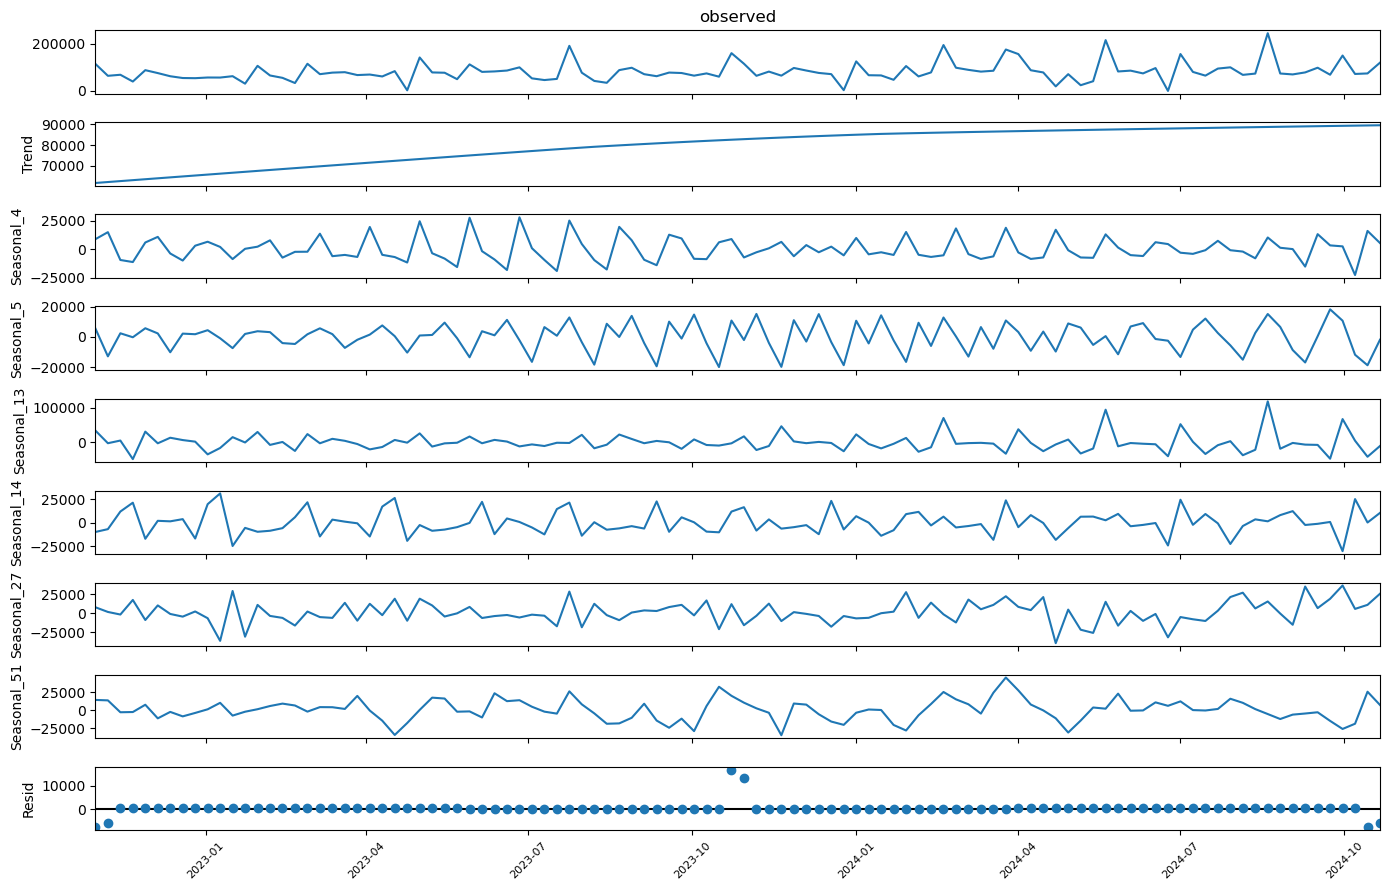

In [429]:
serie_semanal = df_dataset.groupby('week_date')['units_sold'].sum()

result = MSTL(
    serie_semanal,
    periods=(4,5,13,14,27,51)
).fit()

fig = result.plot()
fig.set_size_inches(14, 9)

for ax in fig.axes:
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

Teste Ljung-Box (p-value > 0.05 = bom):
      lb_stat  lb_pvalue
10  24.445098   0.006503
20  24.787011   0.209701
30  24.814873   0.733978

Shapiro-Wilk test (p-value > 0.05 = normal):
p-value: 0.0000


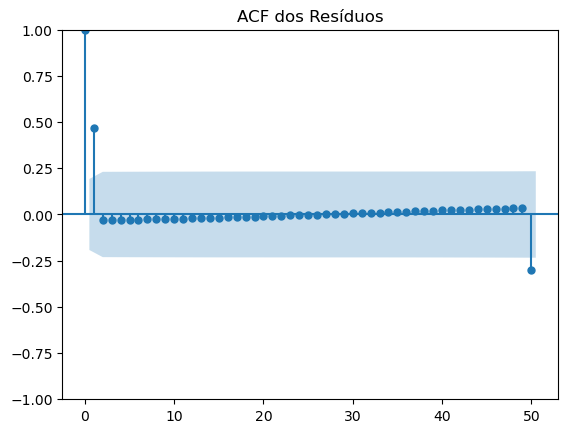

In [436]:
import numpy as np
from scipy import stats

# 1. Teste de autocorrelação nos resíduos
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(result.resid, lags=[10, 20, 30], return_df=True)

print("Teste Ljung-Box (p-value > 0.05 = bom):")
print(ljung_box)

# Se p-value < 0.05 → ainda há autocorrelação (padrão não capturado)
# Se p-value > 0.05 → resíduos são ruído branco (bom!)

# 2. Normalidade dos resíduos
shapiro_test = stats.shapiro(result.resid)

print(f"\nShapiro-Wilk test (p-value > 0.05 = normal):")
print(f"p-value: {shapiro_test.pvalue:.4f}")

# 3. Visualizar ACF dos resíduos
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(result.resid, lags=50)
plt.title('ACF dos Resíduos')
plt.show()

# Se ACF está DENTRO das bandas → bom (ruído branco)
# Se ACF tem picos FORA das bandas → ainda há padrão

#Lot of noise in the weekly series good for hierachical reconciliation, maybe because of sparse series

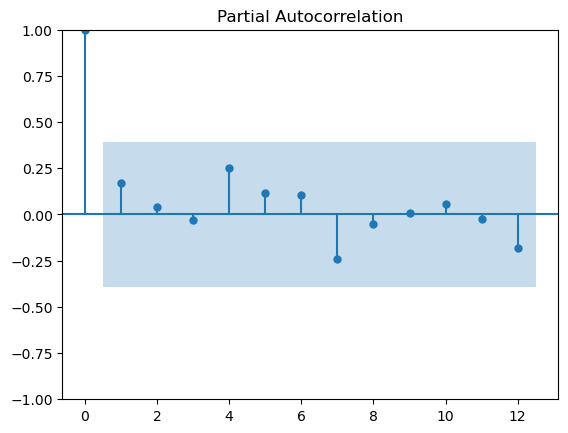

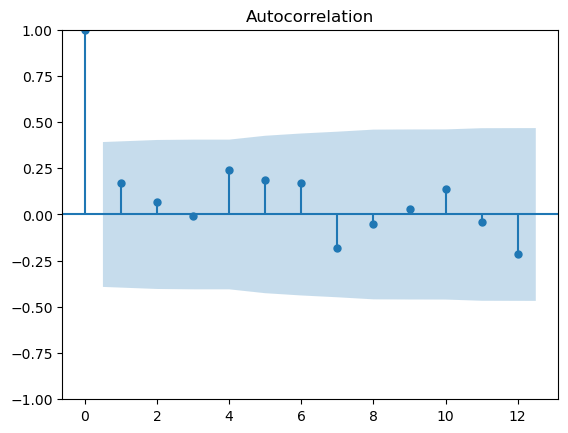

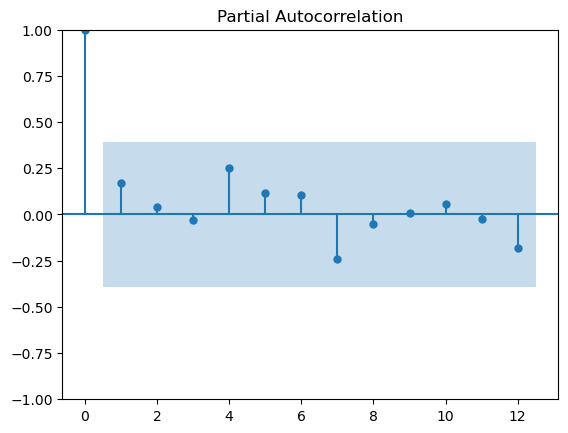

In [437]:
#auto correlation plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_total_sales_monthly['units_sold'], lags=12)
plot_pacf(df_total_sales_monthly['units_sold'], lags=12)

#It implies that in cicle of 12 months we have as trong correlation on lag 4 that can be related to the cicle of the stock refresh

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\510511513.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total_sales_region = df_dataset.groupby('region_name')['units_sold'].sum().reset_index().sort_values('units_sold', ascending=False)


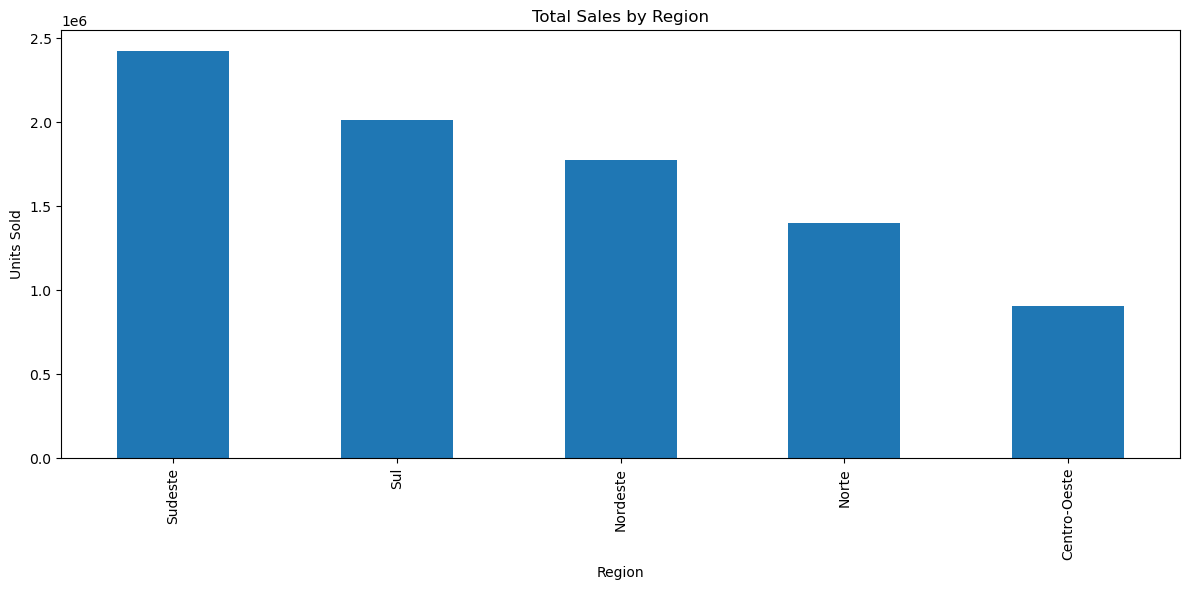

In [442]:
#Analyse total sales by region
df_total_sales_region = df_dataset.groupby('region_name')['units_sold'].sum().reset_index().sort_values('units_sold', ascending=False)
df_total_sales_region.plot(x='region_name', y='units_sold', kind='bar', figsize=(12,6), legend=False)
plt.xlabel('Region')
plt.ylabel('Units Sold')
plt.title('Total Sales by Region')
plt.tight_layout()

In [443]:
df_total_sales_monthly_region.head()

,month,region_name,units_sold
0,2022-10,Centro-Oeste,14702.0
1,2022-10,Nordeste,18442.0
2,2022-10,Norte,17640.0
3,2022-10,Sudeste,31974.0
4,2022-10,Sul,31823.0


### Region

In [445]:
pd.read_csv('../../data/raw/dataset-case-iqvia.csv')

,week_dt,dsupp_id,product_id,region_nm,units_qty,product_attr_1,product_attr_2,product_attr_3
0,2024-03-31,6,233,Norte,6.0,B,C,B24
1,2024-03-01,6,233,Norte,1.0,B,C,B24
2,2024-08-01,6,233,Norte,1.0,B,C,B24
3,2024-09-29,6,233,Norte,1.0,B,C,B24
4,2024-05-01,6,233,Norte,3.0,B,C,B24
...,...,...,...,...,...,...,...,...
147289,2024-07-07,6,36,Norte,51.0,C,B,B04
147290,2024-07-07,6,36,Nordeste,135.0,C,B,B04
147291,2024-08-25,6,36,Nordeste,644.0,C,B,B04
147292,2024-08-25,6,36,Norte,243.0,C,B,B04


In [449]:
df_raw.columns

Index(['week_dt', 'dsupp_id', 'product_id', 'region_nm', 'units_qty',
       'product_attr_1', 'product_attr_2', 'product_attr_3', 'year', 'month'],
      dtype='object')

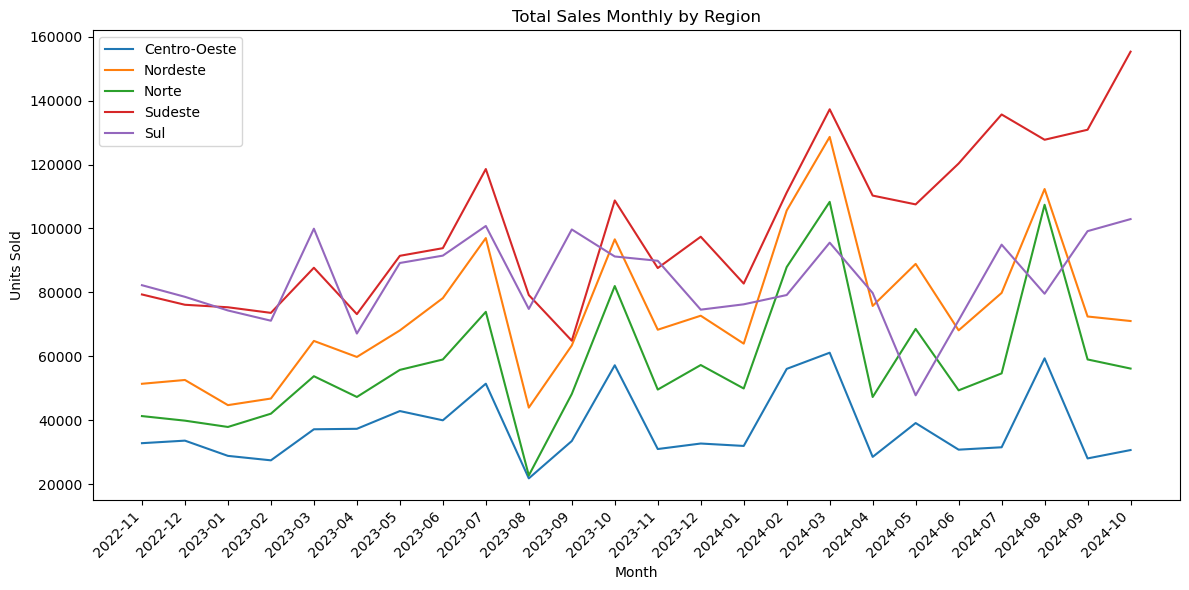

In [452]:
df_raw = pd.read_csv('../../data/raw/dataset-case-iqvia.csv', parse_dates=['week_dt'])
df_raw['year'] = df_raw['week_dt'].dt.year
df_raw['month'] = df_raw['week_dt'].dt.month

df_total_sales_monthly_region = (
    df_raw
    .groupby(['year', 'month', 'region_nm'], observed=True)
    .agg(units_sold=('units_qty', 'sum'))
    .reset_index()
    .assign(period=lambda x: pd.to_datetime(x[['year', 'month']].assign(day=1)))
    .sort_values('period')
)

plt.figure(figsize=(12,6))
for region in df_total_sales_monthly_region['region_nm'].unique():
    region_data = df_total_sales_monthly_region[df_total_sales_monthly_region['region_nm'] == region]
    plt.plot(region_data['period'].dt.strftime('%Y-%m'), region_data['units_sold'], label=region)
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(rotation=45, ha='right')
plt.title('Total Sales Monthly by Region')
plt.legend()
plt.tight_layout()
plt.show()

In [456]:
df_total_sales_monthly_region.describe()

,year,month,units_sold,period
count,180.000000,180.000000,180.0,180
mean,2023.000000,6.500000,47317.633333,2023-06-16 18:40:00
min,2022.000000,1.000000,0.0,2022-01-01 00:00:00
25%,2022.000000,3.750000,0.0,2022-09-23 12:00:00
50%,2023.000000,6.500000,45497.5,2023-06-16 00:00:00
75%,2024.000000,9.250000,77113.0,2024-03-08 18:00:00
max,2024.000000,12.000000,171988.0,2024-12-01 00:00:00
std,0.818774,3.461682,40850.410735,NaN


C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\2149254022.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['month_date', 'region_name'])


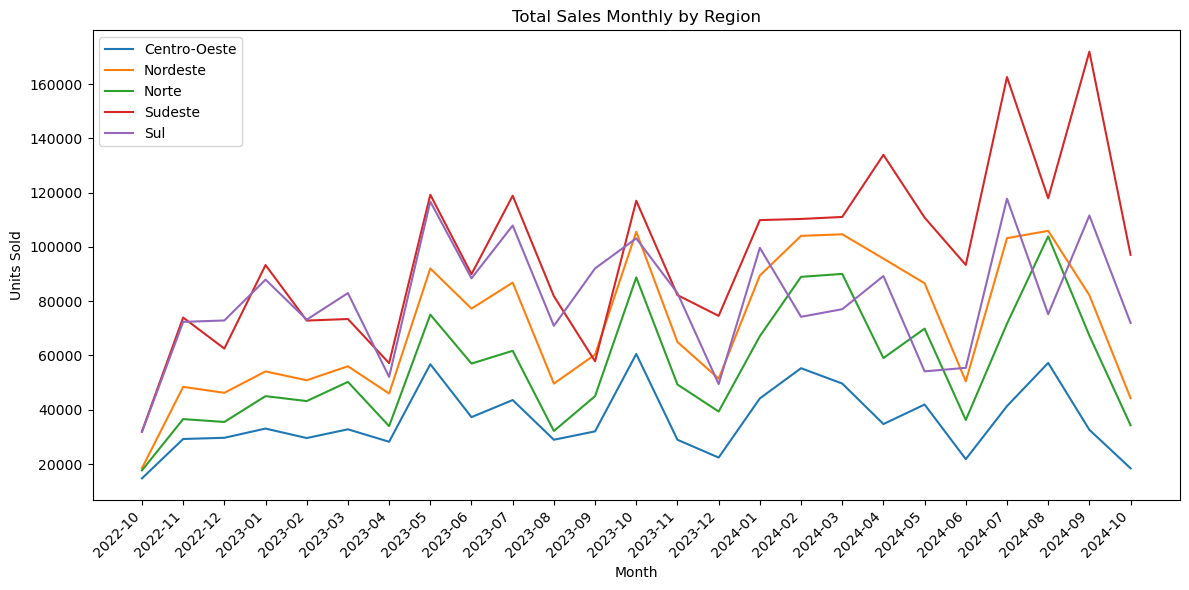

In [462]:
df_total_sales_monthly_region = (
    df_dataset
    .groupby(['month_date', 'region_name'])
    .agg(units_sold=('units_sold', 'sum'))
    .reset_index()
)

plt.figure(figsize=(12,6))
for region in df_total_sales_monthly_region['region_name'].unique():
    region_data = df_total_sales_monthly_region[df_total_sales_monthly_region['region_name'] == region]
    plt.plot(region_data['month_date'].dt.strftime('%Y-%m'), region_data['units_sold'], label=region)
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(rotation=45, ha='right')
plt.title('Total Sales Monthly by Region')
plt.legend()
plt.tight_layout()
plt.show()

In [463]:
from tslearn.metrics import dtw
from tslearn.clustering import TimeSeriesKMeans
from sklearn.preprocessing import StandardScaler

df_total_sales_monthly_region_pivot = df_total_sales_monthly_region.pivot(index='month_date', columns='region_name', values='units_sold').fillna(0)
scaler = StandardScaler()
df_total_sales_monthly_region_scaled = scaler.fit_transform(df_total_sales_monthly_region_pivot)
model = TimeSeriesKMeans(n_clusters=3, metric="dtw", max_iter=10, random_state=42)
clusters = model.fit_predict(df_total_sales_monthly_region_scaled.T)
df_clusters = pd.DataFrame({'region_name': df_total_sales_monthly_region_pivot.columns, 'cluster': clusters})
print(df_clusters)

    region_name  cluster
0  Centro-Oeste        2
1      Nordeste        1
2         Norte        1
3       Sudeste        0
4           Sul        2


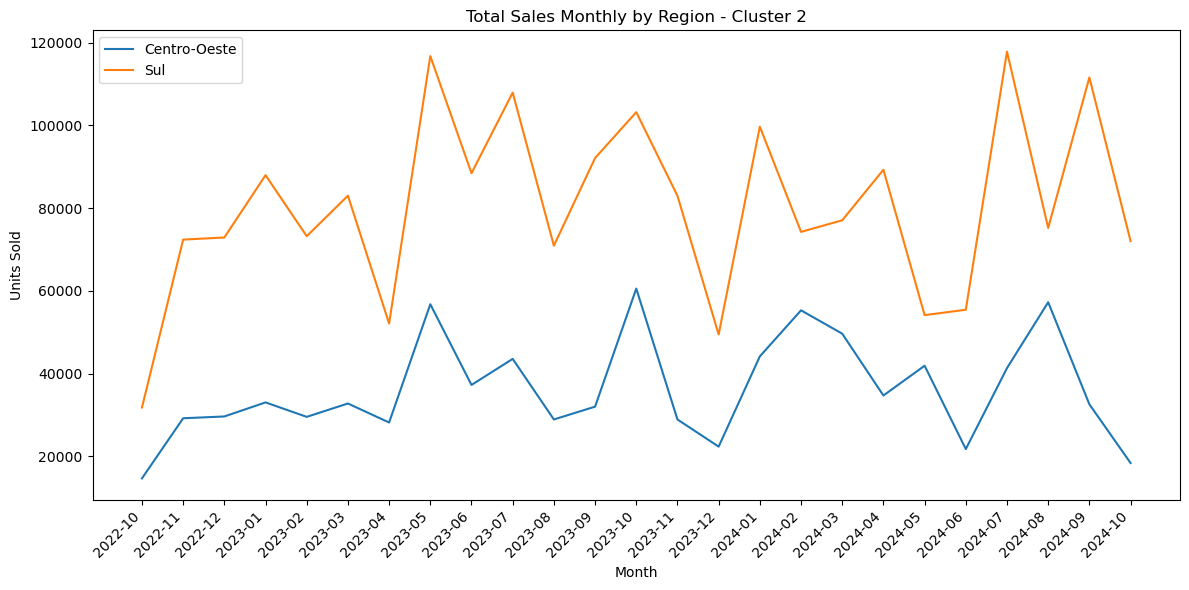

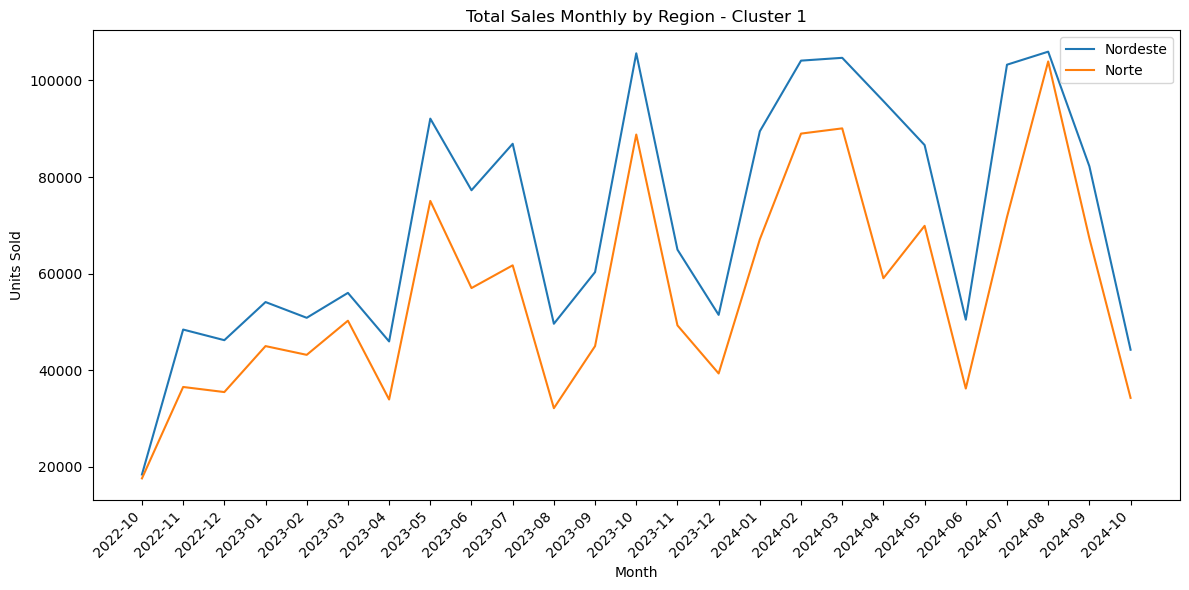

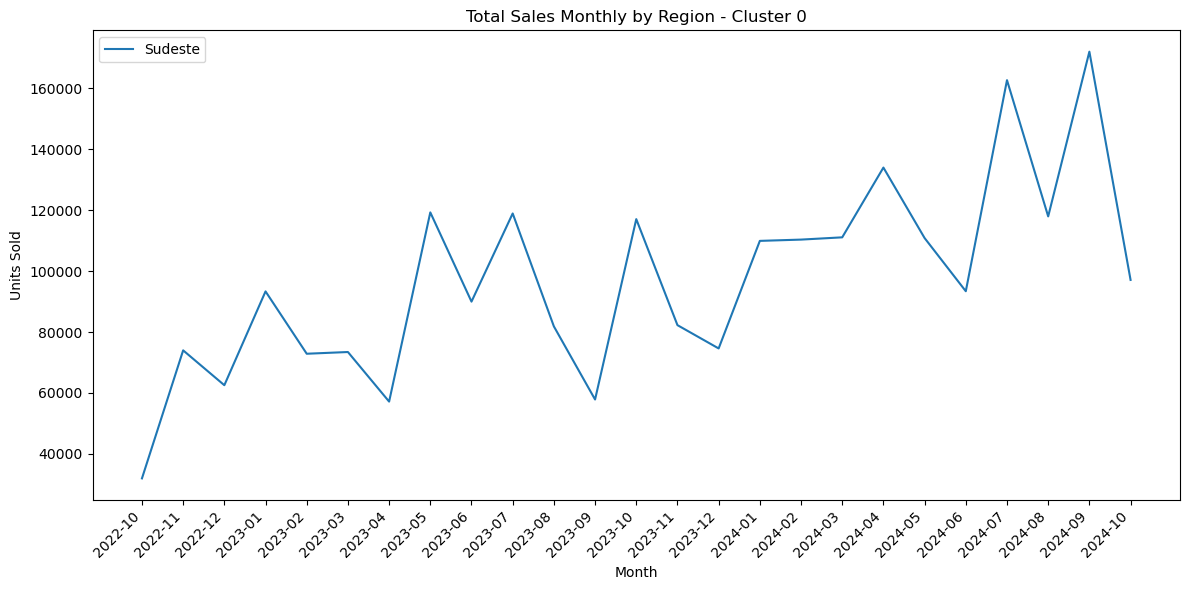

In [464]:
df_total_sales_monthly_region_clustered = df_total_sales_monthly_region.merge(df_clusters, on='region_name')
for cluster in df_clusters['cluster'].unique():
    cluster_data = df_total_sales_monthly_region_clustered[df_total_sales_monthly_region_clustered['cluster'] == cluster]
    plt.figure(figsize=(12,6))
    for region in cluster_data['region_name'].unique():
        region_data = cluster_data[cluster_data['region_name'] == region]
        plt.plot(region_data['month_date'].dt.strftime('%Y-%m'), region_data['units_sold'], label=region)
    plt.xlabel('Month')
    plt.ylabel('Units Sold')
    plt.title(f'Total Sales Monthly by Region - Cluster {cluster}')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

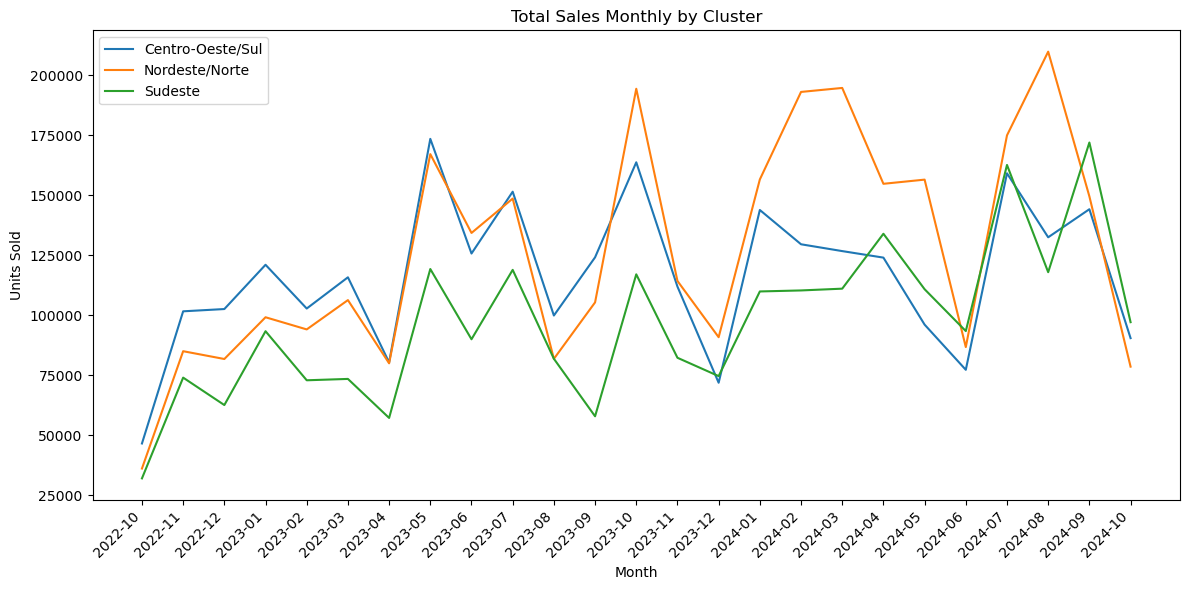

In [466]:
df_total_sales_monthly_cluster = df_total_sales_monthly_region_clustered.groupby(['month_date', 'cluster']).agg(
    units_sold=('units_sold', 'sum')
).reset_index()

plt.figure(figsize=(12,6))
for cluster in df_clusters['cluster'].unique():
    cluster_regions = df_clusters[df_clusters['cluster'] == cluster]['region_name'].tolist()
    cluster_name = '/'.join(cluster_regions)
    cluster_data = df_total_sales_monthly_cluster[df_total_sales_monthly_cluster['cluster'] == cluster]
    plt.plot(cluster_data['month_date'].dt.strftime('%Y-%m'), cluster_data['units_sold'], label=cluster_name)
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(rotation=45, ha='right')
plt.title('Total Sales Monthly by Cluster')
plt.legend()
plt.tight_layout()
plt.show()

#All series by reagion tends to grow and volatility as well, sudeste is more stable, sul and centro-oeste more volatilty, sul has the tragedy of the flood (april-24) can justify 2 diferent ciclesm 

### Supplier analysis

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\3071512273.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ 'month_date', 'supplier_name'])


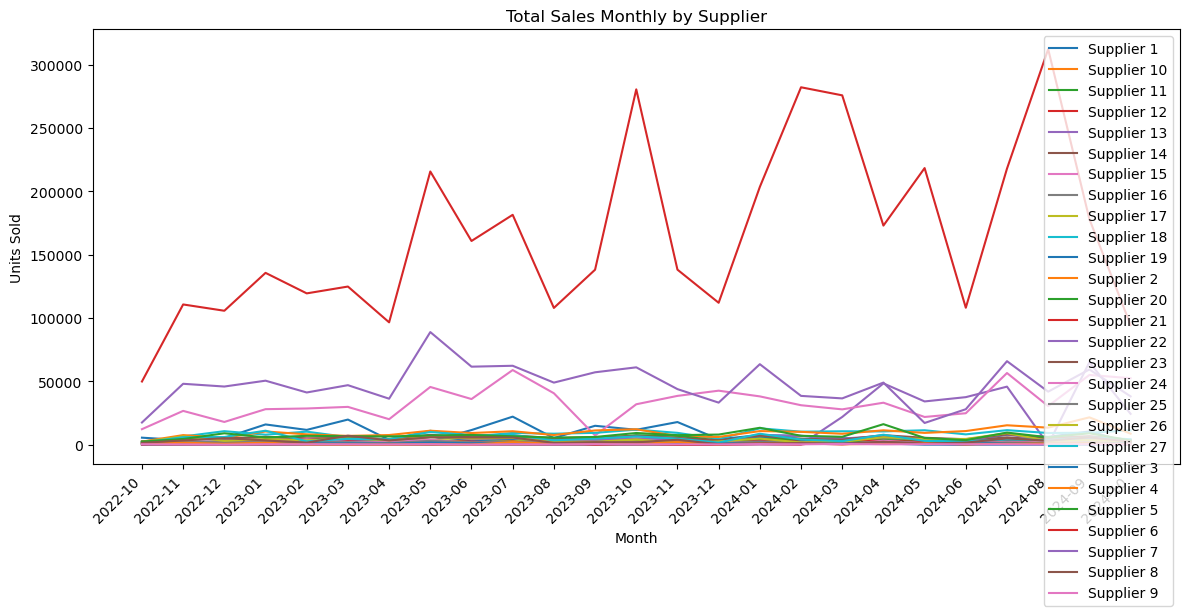

In [468]:
df_total_sales_monthly_supprier = (
    df_dataset
    .groupby([ 'month_date', 'supplier_name'])
    .agg(units_sold=('units_sold', 'sum'))
    .reset_index()
)

plt.figure(figsize=(12,6))
for supplier in df_total_sales_monthly_supprier['supplier_name'].unique():
    supplier_data = df_total_sales_monthly_supprier[df_total_sales_monthly_supprier['supplier_name'] == supplier]
    plt.plot(supplier_data['month_date'].dt.strftime('%Y-%m'), supplier_data['units_sold'], label=supplier)
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(rotation=45, ha='right')
plt.title('Total Sales Monthly by Supplier')
plt.legend()
plt.tight_layout()
plt.show()

In [469]:
df_total_sales_monthly_supprier.groupby('supplier_name', observed=True)['units_sold'].sum().sort_values(ascending=False).head()

supplier_name
Supplier 6     4140624
Supplier 7     1181271
Supplier 15     836079
Supplier 13     279401
Supplier 2      242967
Name: units_sold, dtype: Int64

#supplier 6 is much more higher than the others, we can try to analyze it separately

In [470]:
df_dataset.pivot_table(
    index='product_name',
    columns='supplier_name',
    values='units_sold',
    aggfunc='sum',
    fill_value=0
)

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\1288981583.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_dataset.pivot_table(


supplier_name,Supplier 1,Supplier 10,Supplier 11,Supplier 12,Supplier 13,Supplier 14,Supplier 15,Supplier 16,Supplier 17,Supplier 18,Supplier 19,Supplier 2,Supplier 20,Supplier 21,Supplier 22,Supplier 23,Supplier 24,Supplier 25,Supplier 26,Supplier 27,Supplier 3,Supplier 4,Supplier 5,Supplier 6,Supplier 7,Supplier 8,Supplier 9
product_name,,,,,,,,,,,,,,,,,,,,,,,,,,,
Product 1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43,0,0,0,0,0,0,0,66,0,0,0
Product 10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3539,0,0
Product 100,0,0,266,0,0,0,0,20,0,0,0,0,0,0,101,816,0,587,0,0,23,0,0,10098,2401,0,0
Product 101,0,0,10,0,0,0,0,0,0,0,0,1451,0,0,0,0,0,412,0,0,0,0,0,196,0,0,0
Product 102,0,0,2216,0,0,103,0,0,0,0,0,0,0,0,357,294,0,40,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Product 95,0,0,0,0,0,17,0,2183,0,0,0,0,0,0,0,349,2,0,0,0,37,0,0,3142,0,165,0
Product 96,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,245,0,0,0
Product 97,5,60,0,0,0,0,3989,0,0,1165,0,0,535,0,12,0,0,0,1252,0,52,5,0,12135,5007,0,8


Same product can be supplied by different suppliers, and the same supplier can supply different products. This creates a complex hierarchy that can be explored for forecasting. We can analyze the sales by product and supplier to identify patterns and trends that can inform our forecasting models.

### products

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\2601904850.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ 'month_date', 'product_name'])


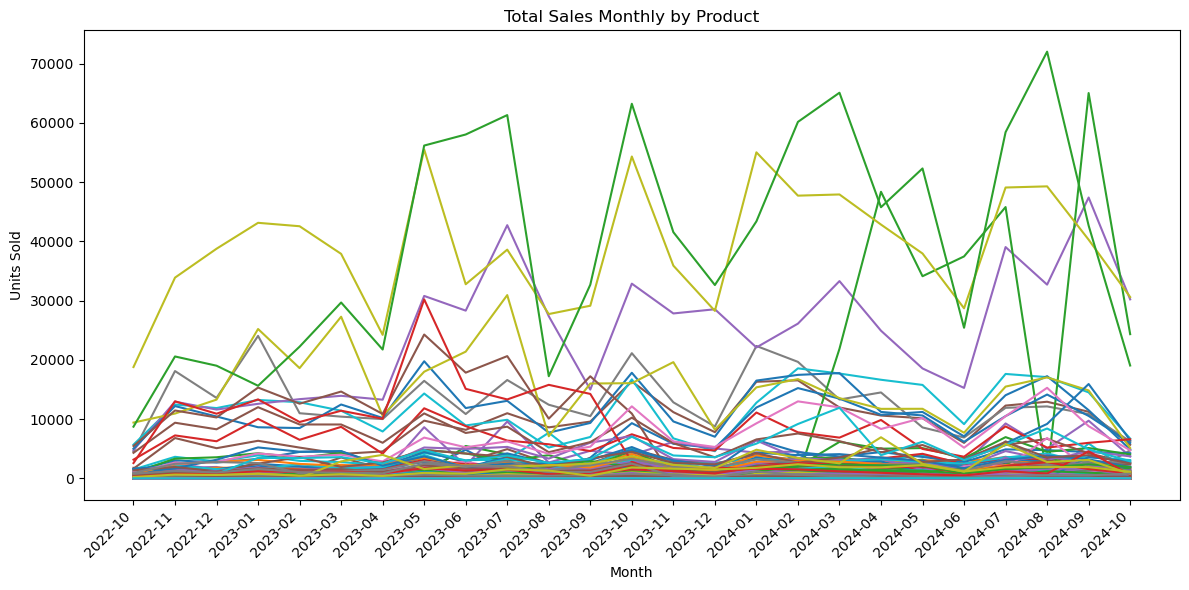

In [471]:
df_total_sales_monthly_product = (
    df_dataset
    .groupby([ 'month_date', 'product_name'])
    .agg(units_sold=('units_sold', 'sum'))
    .reset_index()
    )

plt.figure(figsize=(12,6))
for product in df_total_sales_monthly_product['product_name'].unique():
    product_data = df_total_sales_monthly_product[df_total_sales_monthly_product['product_name'] == product]
    plt.plot(product_data['month_date'].dt.strftime('%Y-%m'), product_data['units_sold'], label=product)
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(rotation=45, ha='right')
plt.title('Total Sales Monthly by Product')
plt.tight_layout()
plt.show()

In [472]:
df_total_sales_monthly_product.groupby('product_name', observed=True)['units_sold'].sum().sort_values()

product_name
Product 143       100
Product 1         109
Product 32        110
Product 82        115
Product 233       116
                ...  
Product 123    327713
Product 241    381948
Product 166    605441
Product 205    970702
Product 326    984563
Name: units_sold, Length: 390, dtype: Int64

#Lot variability in products dimension even by monthly sales. This can be a problem for modeling, since some products have very low sales and others have very high sales. We can try to group products by clustering.

In [473]:
from hierarchicalforecast.utils import aggregate

# 1. Preparar o dataframe no formato esperado (unique_id, ds, y)
df_hier = (
    df_dataset[['week_date', 'supplier_name', 'region_name', 'product_name', 'units_sold']]
    .rename(columns={'week_date': 'ds', 'units_sold': 'y'})
    .copy()
)

# 2. Definir a hierarquia agrupada (spec = do mais agregado ao bottom)
# "Total" é adicionado automaticamente pela função
spec = [
    ['supplier_name'],                                    # 27 séries
    ['region_name'],                                      # 5 séries
    ['supplier_name', 'region_name'],                     # ~130 séries
    ['supplier_name', 'region_name', 'product_name'],     # 2.841 séries (bottom)
]

# 3. Gerar Y_df, S_df e tags
Y_df, S_df, tags = aggregate(df=df_hier, spec=spec)

print(f"Total de séries: {S_df.shape[0]}")
print(f"Séries bottom-level: {S_df.shape[1]}")
print("\nNíveis e quantidades:")
for level, ids in tags.items():
    print(f"  {level}: {len(ids)} séries")


c:\Users\eduar\AppData\Local\anaconda3\envs\or-env\lib\site-packages\narwhals\_pandas_like\expr.py:273: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_native = df._native_frame.groupby(partition_by)[
c:\Users\eduar\AppData\Local\anaconda3\envs\or-env\lib\site-packages\narwhals\_pandas_like\expr.py:273: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_native = df._native_frame.groupby(partition_by)[
c:\Users\eduar\AppData\Local\anaconda3\envs\or-env\lib\site-packages\narwhals\_pandas_like\expr.py:273: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version

Total de séries: 2925
Séries bottom-level: 2842

Níveis e quantidades:
  supplier_name: 27 séries
  region_name: 5 séries
  supplier_name/region_name: 52 séries
  supplier_name/region_name/product_name: 2841 séries


In [474]:
Y_df

,unique_id,ds,y
0,Supplier 1,2022-10-31,5519
1,Supplier 1,2022-11-07,863
2,Supplier 1,2022-11-14,1101
3,Supplier 1,2022-11-21,523
4,Supplier 1,2022-11-28,1057
...,...,...,...
210755,Supplier 9/Nordeste/Product 98,2024-08-05,0
210756,Supplier 9/Nordeste/Product 98,2024-08-12,0
210757,Supplier 9/Nordeste/Product 98,2024-08-19,0
210758,Supplier 9/Nordeste/Product 98,2024-08-26,0


In [485]:
Y_df.isnull().sum()

unique_id    0
ds           0
y            0
dtype: int64

In [486]:
def classify_series(y: pd.Series) -> str:
    """
    Croston demand classification (ADI × CV²).

    ADI = total periods / non-zero periods  (average demand interval)
    CV² = (std / mean)² of non-zero demand quantities
    ddof=0 avoids NaN when only one non-zero observation exists —
    a single sale has zero size variability by definition (CV²=0),
    so classification falls back to ADI only.

    Thresholds (Syntetos et al. 2005):
        ADI < 1.32  &  CV² < 0.49  → Smooth
        ADI < 1.32  &  CV² >= 0.49 → Erratic
        ADI >= 1.32 &  CV² < 0.49  → Intermittent
        ADI >= 1.32 &  CV² >= 0.49 → Lumpy
    """
    non_zero = y[y > 0]
    if len(non_zero) == 0:
        return 'Empty'

    adi = len(y) / len(non_zero)
    cv2 = (non_zero.std(ddof=0) / non_zero.mean()) ** 2

    if adi < 1.32:
        return 'Smooth' if cv2 < 0.49 else 'Erratic'
    else:
        return 'Intermittent' if cv2 < 0.49 else 'Lumpy'


demand_profile = (
    Y_df.groupby('unique_id')['y']
    .apply(classify_series)
    .reset_index()
    .rename(columns={'y': 'demand_type'})
)

demand_profile['level'] = demand_profile['unique_id'].apply(
    lambda x: 'bottom' if x.count('/') == 2 else ('total' if x == 'Total' else 'mid')
)

print(demand_profile.groupby(['level', 'demand_type']).size().unstack(fill_value=0))

demand_type  Erratic  Intermittent  Lumpy  Smooth
level                                            
bottom           840           855    780     366
mid               24             5     11      44


<Axes: xlabel='demand_type'>

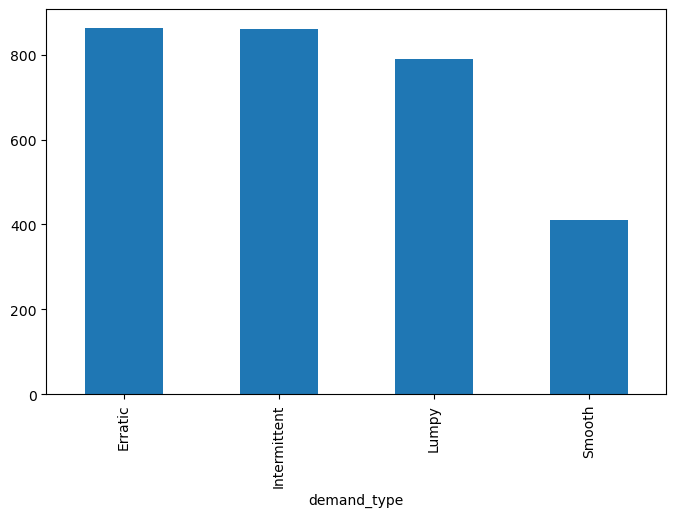

In [488]:
demand_profile.groupby('demand_type').size().plot(kind='bar', figsize=(8,5))

In [476]:
zero_pct = (
    Y_df.groupby('unique_id')['y']
    .apply(lambda x: (x == 0).mean())
    .reset_index()
    .rename(columns={'y': 'zero_pct'})
)

# distribuição por nível
for level_name, ids in tags.items():
    subset = zero_pct[zero_pct['unique_id'].isin(ids)]['zero_pct']
    print(f"{level_name}: mediana zeros = {subset.median():.1%}, max = {subset.max():.1%}")


supplier_name: mediana zeros = 3.8%, max = 30.8%
region_name: mediana zeros = 1.0%, max = 1.0%
supplier_name/region_name: mediana zeros = 6.7%, max = 89.9%
supplier_name/region_name/product_name: mediana zeros = 32.7%, max = 98.7%


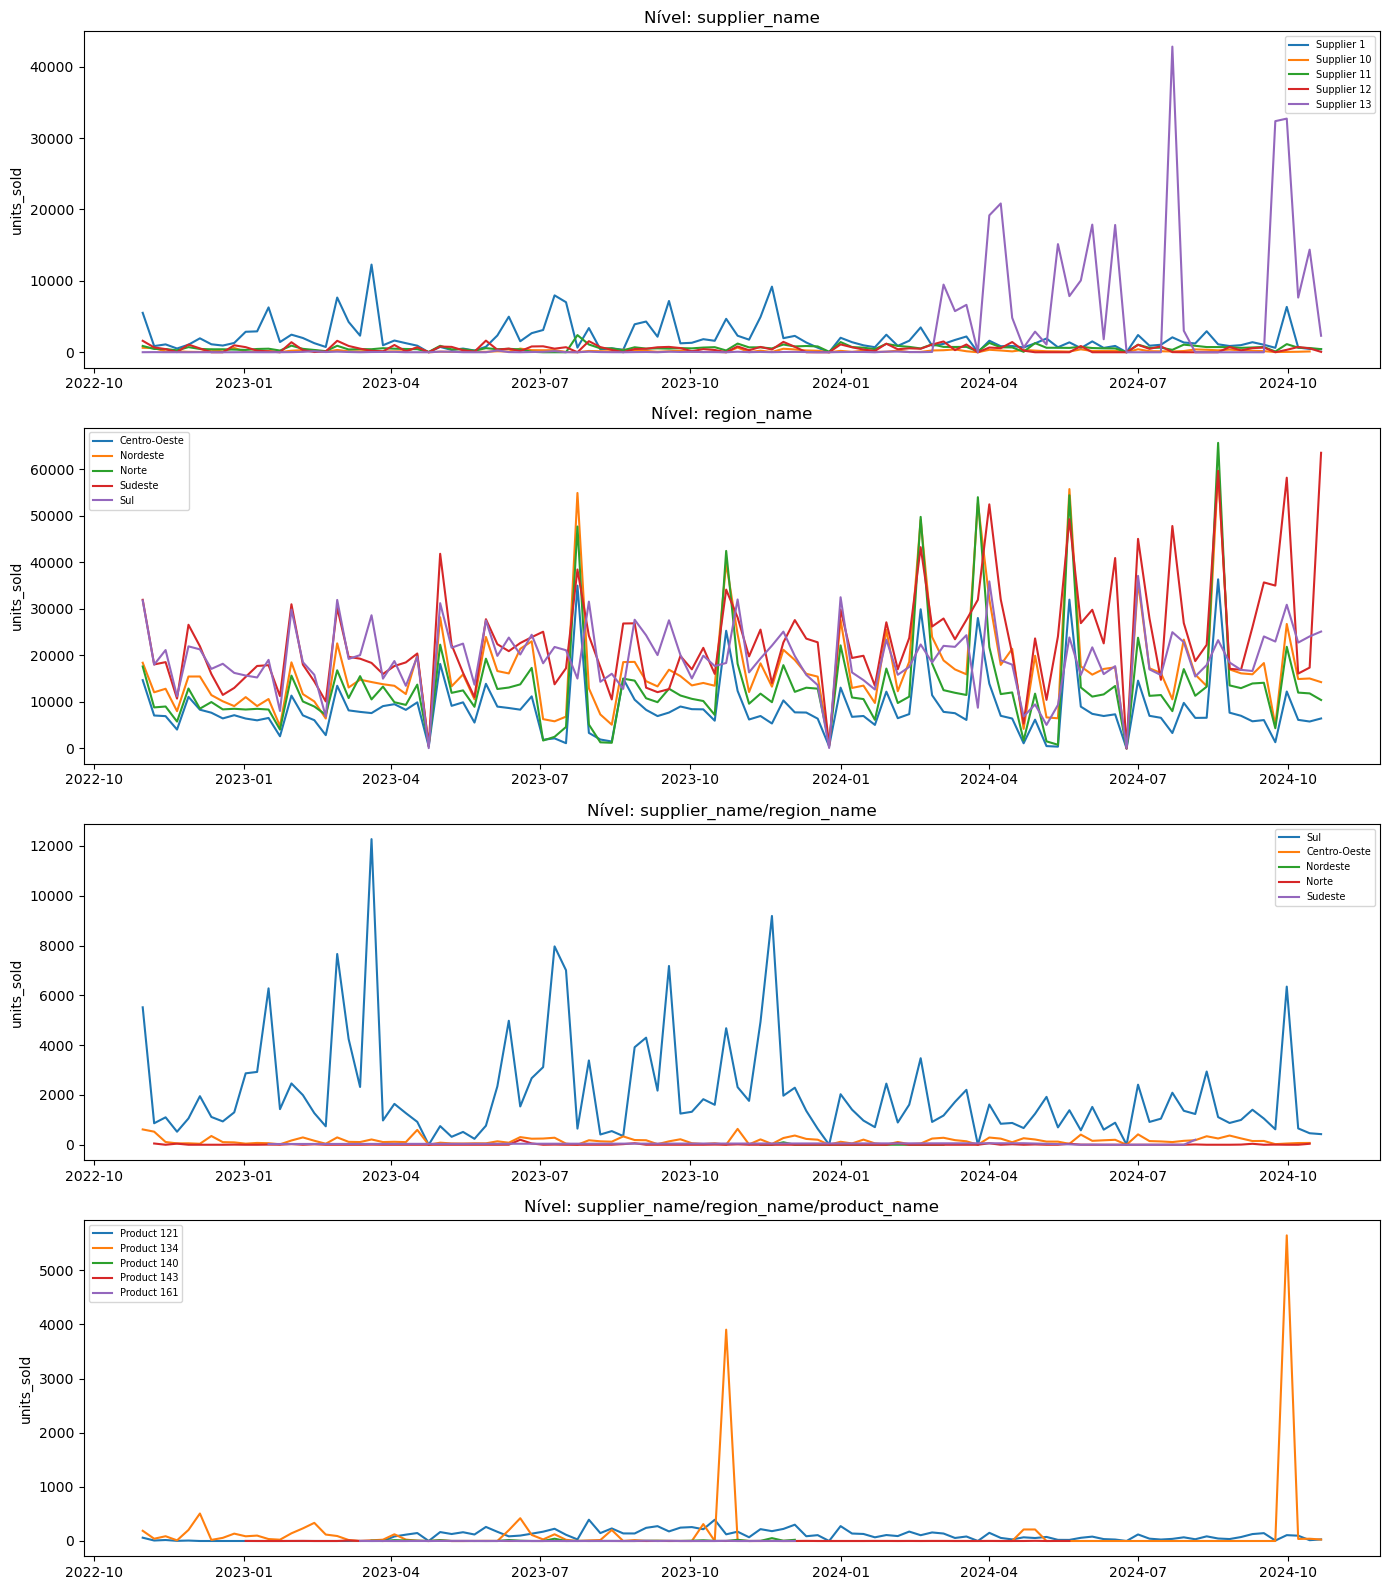

In [477]:
fig, axes = plt.subplots(len(tags), 1, figsize=(14, 4 * len(tags)))

for ax, (level_name, ids) in zip(axes, tags.items()):
    sample_ids = ids[:5] if len(ids) > 5 else ids
    for uid in sample_ids:
        s = Y_df[Y_df['unique_id'] == uid].set_index('ds')['y']
        ax.plot(s.index, s.values, label=uid.split('/')[-1])
    ax.set_title(f'Nível: {level_name}')
    ax.legend(fontsize=7)
    ax.set_ylabel('units_sold')

plt.tight_layout()
plt.show()


In [478]:
# Todas as séries bottom-level do Product 134
p134_bottom = Y_df[
    Y_df['unique_id'].str.endswith('Product 134')
]

# Detectar outlier por série com z-score
from scipy import stats
import numpy as np
import pandas as pd

outlier_report = []

for uid, group in p134_bottom.groupby('unique_id'):
    # Resetar index para facilitar manipulação
    group = group.reset_index(drop=True)
    y = group['y'].values
    
    # Filtrar apenas valores positivos
    positive_mask = y > 0
    
    if positive_mask.sum() > 3:  # Precisa de pelo menos 3 valores positivos
        # Calcular z-score apenas nos valores positivos
        y_positive = y[positive_mask]
        z_scores = np.abs(stats.zscore(y_positive))
        
        # Encontrar o pior outlier
        if z_scores.max() > 3:
            # Índice do pior outlier dentro dos valores positivos
            worst_idx_in_positive = z_scores.argmax()
            
            # Mapear de volta para índice original
            positive_indices = np.where(positive_mask)[0]
            worst_idx_original = positive_indices[worst_idx_in_positive]
            
            outlier_report.append({
                'unique_id': uid,
                'ds': group.loc[worst_idx_original, 'ds'],
                'value': group.loc[worst_idx_original, 'y'],
                'zscore': z_scores.max()
            })

# Criar DataFrame e ordenar
if len(outlier_report) > 0:
    df_outliers = pd.DataFrame(outlier_report).sort_values('zscore', ascending=False)
    print("\n📊 Outliers Detectados (Z-score > 3):")
    print(df_outliers.to_string(index=False))
    
    # Estatísticas resumidas
    print(f"\n📈 Total de séries com outliers: {len(df_outliers)}")
    print(f"📈 Z-score máximo: {df_outliers['zscore'].max():.2f}")
    print(f"📈 Z-score médio: {df_outliers['zscore'].mean():.2f}")
else:
    print("\n✅ Nenhum outlier detectado (Z-score > 3)")


📊 Outliers Detectados (Z-score > 3):
                          unique_id         ds  value   zscore
    Supplier 6/Nordeste/Product 134 2024-08-19   1361 5.835094
         Supplier 1/Sul/Product 134 2024-09-30   5646 5.587494
    Supplier 25/Sudeste/Product 134 2022-10-31    236 5.394898
Supplier 6/Centro-Oeste/Product 134 2022-10-31    586 5.178726
     Supplier 6/Sudeste/Product 134 2024-05-20   4873 4.804887
         Supplier 7/Sul/Product 134 2024-10-14    937 4.510668
       Supplier 6/Norte/Product 134 2023-07-24     26 4.448128
         Supplier 4/Sul/Product 134 2023-07-31    985 4.193954
    Supplier 22/Sudeste/Product 134 2024-07-22   2197 4.045862
         Supplier 6/Sul/Product 134 2024-03-25   3107 3.584803

📈 Total de séries com outliers: 10
📈 Z-score máximo: 5.84
📈 Z-score médio: 4.76



📊 RELATÓRIO DE OUTLIERS - Product 134

🔴 Pior outlier por série:
                          unique_id         ds  value   zscore
    Supplier 6/Nordeste/Product 134 2024-08-19   1361 5.835094
         Supplier 1/Sul/Product 134 2024-09-30   5646 5.587494
    Supplier 25/Sudeste/Product 134 2022-10-31    236 5.394898
Supplier 6/Centro-Oeste/Product 134 2022-10-31    586 5.178726
     Supplier 6/Sudeste/Product 134 2024-05-20   4873 4.804887
         Supplier 7/Sul/Product 134 2024-10-14    937 4.510668
       Supplier 6/Norte/Product 134 2023-07-24     26 4.448128
         Supplier 4/Sul/Product 134 2023-07-31    985 4.193954
    Supplier 22/Sudeste/Product 134 2024-07-22   2197 4.045862
         Supplier 6/Sul/Product 134 2024-03-25   3107 3.584803

📊 Estatísticas:
   - Total de séries analisadas: 15
   - Séries com outliers: 10
   - Total de outliers detectados: 23
   - Z-score máximo: 5.84
   - Z-score médio: 4.22

📈 Outliers por série:
unique_id
Supplier 6/Sudeste/Product 134       

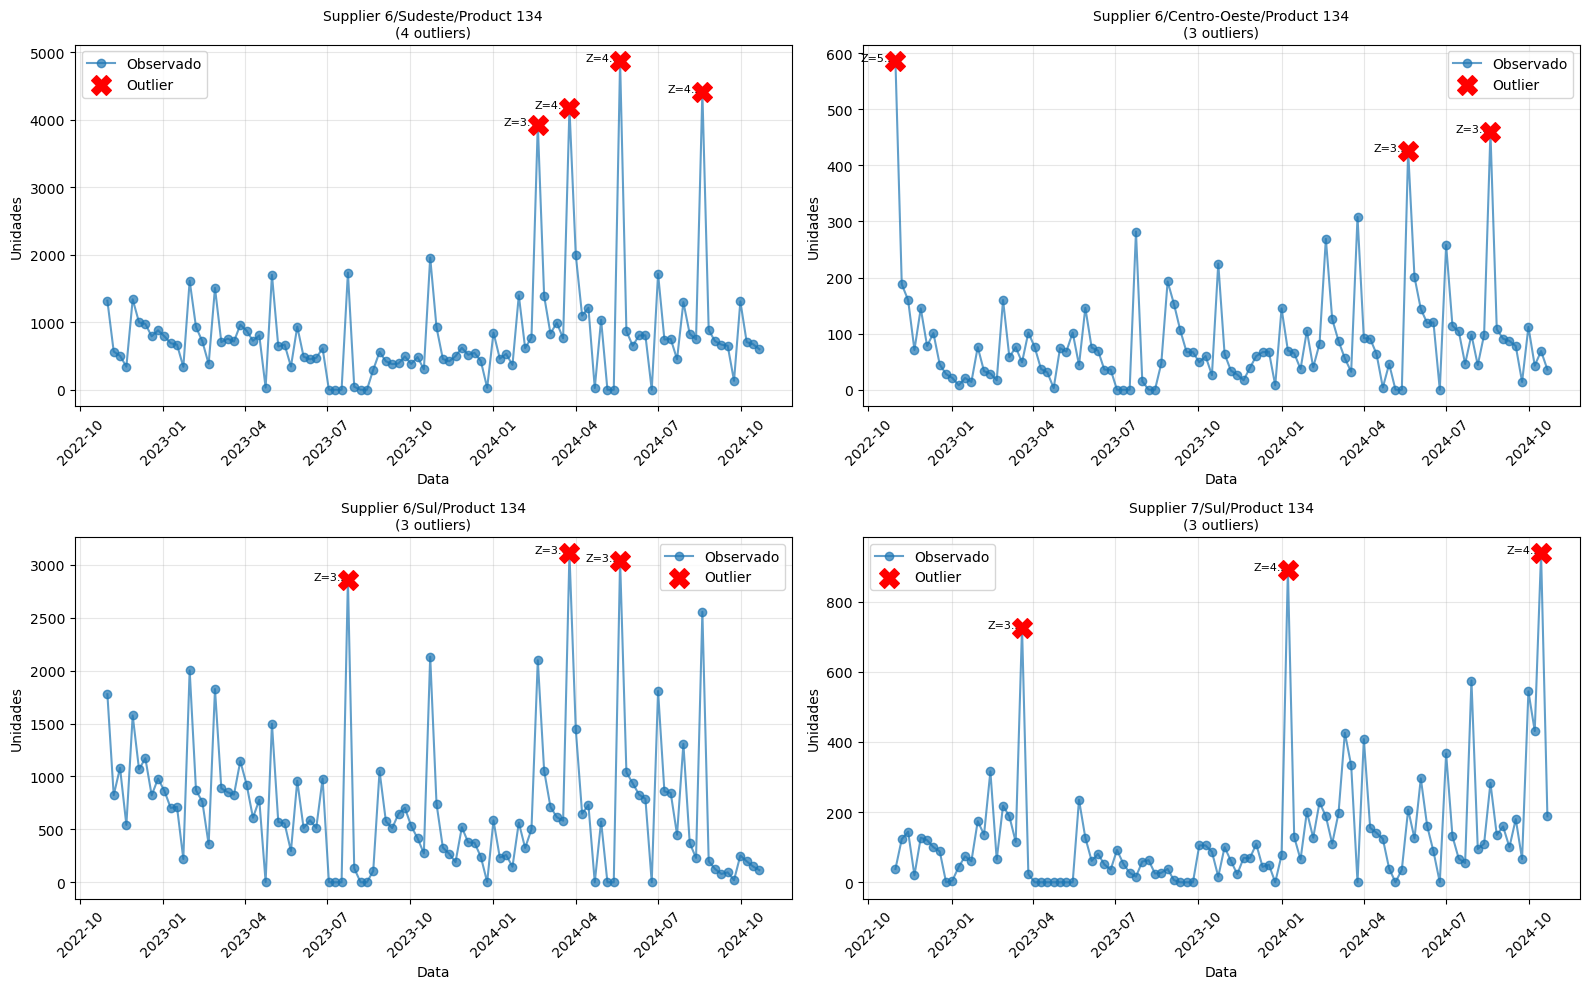

In [479]:
from scipy import stats
import numpy as np
import pandas as pd

# Todas as séries bottom-level do Product 134
p134_bottom = Y_df[
    Y_df['unique_id'].str.endswith('Product 134')
].copy()

# Função para detectar outliers
def detect_outliers(series, threshold=3, method='zscore'):
    """
    Detecta outliers em uma série temporal
    
    Parameters:
    -----------
    series : array-like
        Série temporal
    threshold : float
        Limiar para considerar outlier (padrão: 3 para z-score)
    method : str
        'zscore', 'iqr', ou 'modified_zscore'
    
    Returns:
    --------
    outlier_mask : boolean array
        True onde há outliers
    scores : array
        Scores calculados
    """
    # Filtrar zeros
    mask_nonzero = series > 0
    if mask_nonzero.sum() < 3:
        return np.zeros(len(series), dtype=bool), np.zeros(len(series))
    
    values = series[mask_nonzero]
    
    if method == 'zscore':
        # Z-score padrão
        z = np.abs(stats.zscore(values))
        outlier_idx = z > threshold
        
        # Mapear de volta
        full_scores = np.zeros(len(series))
        full_scores[mask_nonzero] = z
        
        full_outliers = np.zeros(len(series), dtype=bool)
        outlier_positions = np.where(mask_nonzero)[0][outlier_idx]
        full_outliers[outlier_positions] = True
        
        return full_outliers, full_scores
    
    elif method == 'iqr':
        # Interquartile Range (mais robusto a outliers extremos)
        Q1 = np.percentile(values, 25)
        Q3 = np.percentile(values, 75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        
        outlier_idx = (values < lower_bound) | (values > upper_bound)
        
        # Calcular "score" como distância normalizada
        scores = np.maximum(
            np.abs(values - Q1) / IQR,
            np.abs(values - Q3) / IQR
        )
        
        # Mapear de volta
        full_scores = np.zeros(len(series))
        full_scores[mask_nonzero] = scores
        
        full_outliers = np.zeros(len(series), dtype=bool)
        outlier_positions = np.where(mask_nonzero)[0][outlier_idx]
        full_outliers[outlier_positions] = True
        
        return full_outliers, full_scores
    
    elif method == 'modified_zscore':
        # Modified Z-score (usa mediana, mais robusto)
        median = np.median(values)
        mad = np.median(np.abs(values - median))
        
        if mad == 0:
            mad = np.mean(np.abs(values - median))
        
        modified_z = 0.6745 * (values - median) / mad if mad > 0 else np.zeros(len(values))
        outlier_idx = np.abs(modified_z) > threshold
        
        # Mapear de volta
        full_scores = np.zeros(len(series))
        full_scores[mask_nonzero] = np.abs(modified_z)
        
        full_outliers = np.zeros(len(series), dtype=bool)
        outlier_positions = np.where(mask_nonzero)[0][outlier_idx]
        full_outliers[outlier_positions] = True
        
        return full_outliers, full_scores

# Detectar outliers por série
outlier_report = []

for uid, group in p134_bottom.groupby('unique_id'):
    group = group.reset_index(drop=True).copy()
    y = group['y'].values
    
    # Detectar com Z-score
    outlier_mask, scores = detect_outliers(y, threshold=3, method='zscore')
    
    # Se houver outliers
    if outlier_mask.any():
        # Pegar todos os outliers (não só o pior)
        outlier_indices = np.where(outlier_mask)[0]
        
        for idx in outlier_indices:
            outlier_report.append({
                'unique_id': uid,
                'ds': group.loc[idx, 'ds'],
                'value': group.loc[idx, 'y'],
                'zscore': scores[idx],
                'is_highest': idx == scores.argmax()  # Marcar o pior
            })

# Criar DataFrame
if len(outlier_report) > 0:
    df_outliers = pd.DataFrame(outlier_report).sort_values(['unique_id', 'zscore'], ascending=[True, False])
    
    print("\n" + "="*80)
    print("📊 RELATÓRIO DE OUTLIERS - Product 134")
    print("="*80)
    
    # Mostrar apenas o pior de cada série
    print("\n🔴 Pior outlier por série:")
    df_worst = df_outliers[df_outliers['is_highest']].sort_values('zscore', ascending=False)
    print(df_worst[['unique_id', 'ds', 'value', 'zscore']].to_string(index=False))
    
    # Estatísticas
    print(f"\n📊 Estatísticas:")
    print(f"   - Total de séries analisadas: {p134_bottom['unique_id'].nunique()}")
    print(f"   - Séries com outliers: {df_worst.shape[0]}")
    print(f"   - Total de outliers detectados: {len(df_outliers)}")
    print(f"   - Z-score máximo: {df_outliers['zscore'].max():.2f}")
    print(f"   - Z-score médio: {df_outliers['zscore'].mean():.2f}")
    
    # Distribuição por série
    print(f"\n📈 Outliers por série:")
    outlier_counts = df_outliers.groupby('unique_id').size().sort_values(ascending=False)
    print(outlier_counts.head(10))
    
else:
    print("\n✅ Nenhum outlier detectado (Z-score > 3)")

# Opcional: Visualizar outliers
if len(outlier_report) > 0:
    import matplotlib.pyplot as plt
    
    # Pegar as 4 séries com mais outliers
    top_series = df_outliers.groupby('unique_id').size().nlargest(4).index
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, uid in enumerate(top_series):
        if i >= 4:
            break
            
        # Dados da série
        series_data = p134_bottom[p134_bottom['unique_id'] == uid].copy()
        series_outliers = df_outliers[df_outliers['unique_id'] == uid]
        
        ax = axes[i]
        
        # Plot série completa
        ax.plot(series_data['ds'], series_data['y'], 'o-', label='Observado', alpha=0.7)
        
        # Marcar outliers
        for _, outlier in series_outliers.iterrows():
            ax.scatter(outlier['ds'], outlier['value'], 
                      color='red', s=200, marker='X', 
                      label='Outlier' if _ == series_outliers.index[0] else '', 
                      zorder=5)
            ax.text(outlier['ds'], outlier['value'], 
                   f"Z={outlier['zscore']:.1f}",
                   fontsize=8, ha='right')
        
        ax.set_title(f"{uid}\n({len(series_outliers)} outliers)", fontsize=10)
        ax.set_xlabel('Data')
        ax.set_ylabel('Unidades')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()